In [1]:
### Harmonized combination l8-s2 for vegetation analysis 2013-2025 with NDVI

## Imports and GEE initialization

# Import packages
import os
import ee
import geemap
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

In [2]:
# Initialize Earth Engine with explicit project
ee.Initialize(project='ee-francescofustinoni')
print("EE initialized successfully with project ee-francescofustinoni")

EE initialized successfully with project ee-francescofustinoni


In [3]:
## Inputs, shapefile, cloud masks, combined collection

# Inputs
bolivar_shp_path = r'C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\bolivar.shp'
COARSE_SCALE = 250     # coarse resolution (meters) for trend computation
BASELINE_END = 2018    # baseline end year for anomaly
START_YEAR = 2013
END_YEAR = 2025

# Load shapefile and convert to EE
bolivar_gdf = gpd.read_file(bolivar_shp_path).to_crs(epsg=4326)
bolivar = geemap.gdf_to_ee(bolivar_gdf)  # FeatureCollection or Feature
# Use FeatureCollection geometry for clipping/reduceRegion
region_geom = bolivar.geometry() if hasattr(bolivar, 'geometry') else bolivar.geometry()

# Cloud masks
def mask_landsat_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit = 1 << 3
    snow_bit = 1 << 4
    cloud_bit = 1 << 5
    cirrus_bit = 1 << 7
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(snow_bit).eq(0))
            .And(qa.bitwiseAnd(cloud_bit).eq(0))
            .And(qa.bitwiseAnd(cirrus_bit).eq(0)))
    optical = image.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']).multiply(0.0000275).add(-0.2)
    return optical.updateMask(mask).copyProperties(image, image.propertyNames())

def mask_sentinel2_clouds(image):
    scl = image.select('SCL')
    mask = (scl.neq(3)  # cloud shadow
            .And(scl.neq(8))   # cloud medium probability
            .And(scl.neq(9))   # cloud high probability
            .And(scl.neq(10))  # thin cirrus
            .And(scl.neq(11))) # snow/ice
    optical = image.select('B.*').divide(10000)
    out = optical.updateMask(mask).addBands(scl).copyProperties(image, image.propertyNames())
    return out

# Build combined collection (LANDSAT L8 + Sentinel2 harmonized)
def combined_landsat_sentinel_ndvi(region):
    l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
          .filterBounds(region)
          .filterDate('2013-01-01', '2015-06-22')
          .map(mask_landsat_clouds)
          .map(lambda img: img.select(['SR_B5','SR_B4']).rename(['NIR','RED'])))

    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(region)
          .filterDate('2015-06-23', f'{END_YEAR}-12-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 95))
          .map(mask_sentinel2_clouds)
          .map(lambda img: img.select(['B8','B4']).rename(['NIR','RED'])))

    combined = l8.merge(s2)
    return combined.map(lambda img: img.clip(region))

combined_ic = combined_landsat_sentinel_ndvi(bolivar)

In [4]:
## Yearly NDVI (fine) and coarse collection for trend

def yearly_median_ndvi(ic, start_year, end_year):
    years = ee.List.sequence(start_year, end_year)
    def per_year(y):
        y = ee.Number(y)
        start = ee.Date.fromYMD(y, 1, 1)
        end = ee.Date.fromYMD(y, 12, 31)
        coll = ic.filterDate(start, end)
        median_img = coll.median()
        ndvi = ee.Image(ee.Algorithms.If(coll.size().gt(0),
                                         median_img.normalizedDifference(['NIR','RED']).rename('NDVI'),
                                         ee.Image.constant(-9999).rename('NDVI').selfMask()))
        year_band = ee.Image.constant(y).rename('year').toFloat()
        return ndvi.addBands(year_band).set('year', y)
    return ee.ImageCollection(years.map(per_year))

yearly_ndvi_ic = yearly_median_ndvi(combined_ic, START_YEAR, END_YEAR)

# Keep only years that have at least one valid pixel (server-side decision)
def keep_if_data(img):
    count = ee.Number(img.select('NDVI').reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region_geom,
        scale=30,
        maxPixels=1e12
    ).get('NDVI'))
    # If count > 0, return original image. Else return fully-masked image.
    return ee.Image(ee.Algorithms.If(count.gt(0), img, img.updateMask(ee.Image(0))))

yearly_ndvi_ic_filtered = yearly_ndvi_ic.map(keep_if_data)

# Coarse resample each yearly image (mean) and reproject to COARSE_SCALE for trend
def coarse_resample_year(img):
    reduced = img.select(['NDVI', 'year']).reduceResolution(
        reducer=ee.Reducer.mean(),
        maxPixels=65535
    ).reproject(crs='EPSG:4326', scale=COARSE_SCALE)
    return reduced.clip(region_geom).copyProperties(img, img.propertyNames())

yearly_ndvi_coarse = yearly_ndvi_ic_filtered.map(coarse_resample_year)

In [5]:
## Trend and Pearson correlation on coarse grid, baseline mean, and display helper

# Compute trend on coarse grid (linearFit)
trend_coarse = yearly_ndvi_coarse.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())
slope_coarse = trend_coarse.select('scale').rename('slope').clip(region_geom)
intercept_coarse = trend_coarse.select('offset').rename('offset').clip(region_geom)

# Pearson correlation & p-value
pearson_coarse = yearly_ndvi_coarse.select(['year', 'NDVI']).reduce(ee.Reducer.pearsonsCorrelation())
rho_coarse = pearson_coarse.select('correlation').rename('rho').clip(region_geom)
pval_coarse = pearson_coarse.select('p_value').rename('p_value').clip(region_geom)

# Reproject outputs explicitly to coarse scale / simple CRS (helps the tile server)
slope_coarse = slope_coarse.reproject(crs='EPSG:4326', scale=COARSE_SCALE)
rho_coarse = rho_coarse.reproject(crs='EPSG:4326', scale=COARSE_SCALE)

# Baseline mean (coarse) for anomalies
baseline_collection = yearly_ndvi_ic_filtered.filter(ee.Filter.lte('year', BASELINE_END))
baseline_coarse = baseline_collection.map(coarse_resample_year)
baseline_mean_coarse = baseline_coarse.select('NDVI').mean().rename('NDVI_baseline').clip(region_geom)
baseline_mean_coarse = baseline_mean_coarse.reproject(crs='EPSG:4326', scale=COARSE_SCALE)

# Helper to produce very lightweight display images to avoid EE memory errors when Map.addLayer is called
def make_display_layer(img, scale=COARSE_SCALE):
    """
    Create a 1-band, coarse, simple-projection, low-metadata image for display.
    Ensures the output stays an ee.Image (not a generic Element).
    """

    single_band = img.select([0])   # slope or rho
    
    # Apply clip EARLY while it is certainly an ee.Image
    clipped = single_band.clip(region_geom)

    # Now make coarse + simple
    disp = (
        clipped
        .unmask(-9999)   # avoid sparse tiles
        .float()
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            maxPixels=256
        )
        .reproject(
            crs="EPSG:4326",
            scale=scale
        )
        .copyProperties(img, [])     # remove metadata (keeps light)
    )

    return disp

# Make display-ready layers
slope_disp = make_display_layer(slope_coarse, COARSE_SCALE)
rho_disp = make_display_layer(rho_coarse, COARSE_SCALE)

In [ ]:
## Export to Google Drive (reliable, no memory limit)

print("\n=== EXPORTING TO GOOGLE DRIVE ===\n")

# Utility: Drive folder name
DRIVE_FOLDER = "Bolivar_exports"

# ------------------------------------------------------------
# Export yearly NDVI (fine resolution)
# ------------------------------------------------------------
print("Exporting yearly NDVI (fine resolution)...")

for year in range(START_YEAR, END_YEAR + 1):

    img = yearly_ndvi_ic_filtered.filter(ee.Filter.eq("year", year)).first()
    if img is None:
        print(f"  [skip] No NDVI for {year}")
        continue

    out_name = f"NDVI_fine_{year}"

    task = ee.batch.Export.image.toDrive(
        image=img.select("NDVI"),
        description=out_name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=out_name,
        scale=30,
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {out_name}")

    
# ------------------------------------------------------------
# Export yearly NDVI (coarse resolution)
# ------------------------------------------------------------
print("\nExporting yearly NDVI (coarse resolution)...")

for year in range(START_YEAR, END_YEAR + 1):

    img = yearly_ndvi_coarse.filter(ee.Filter.eq("year", year)).first()
    if img is None:
        print(f"  [skip] No coarse NDVI for {year}")
        continue

    out_name = f"NDVI_coarse_{year}"

    task = ee.batch.Export.image.toDrive(
        image=img.select("NDVI"),
        description=out_name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=out_name,
        scale=COARSE_SCALE,
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {out_name}")


# ------------------------------------------------------------
# Export NDVI anomaly
# ------------------------------------------------------------
print("\nExporting NDVI anomalies...")

for year in range(START_YEAR, END_YEAR + 1):

    img = yearly_ndvi_ic_filtered.filter(ee.Filter.eq("year", year)).first()
    if img is None:
        print(f"  [skip] No NDVI for anomaly {year}")
        continue

    anomaly = img.select("NDVI").subtract(
        baseline_mean_coarse.select("NDVI_baseline")
    ).rename("NDVI_anomaly")

    out_name = f"NDVI_anomaly_{year}"

    task = ee.batch.Export.image.toDrive(
        image=anomaly,
        description=out_name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=out_name,
        scale=COARSE_SCALE,
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {out_name}")


# ------------------------------------------------------------
# Export slope, rho, baseline mean
# ------------------------------------------------------------
print("\nExporting slope, rho, baseline...")

for img, name in [
    (slope_coarse, "NDVI_slope"),
    (rho_coarse, "NDVI_rho"),
    (baseline_mean_coarse, "NDVI_baseline_mean"),
]:

    task = ee.batch.Export.image.toDrive(
        image=img,
        description=name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=name,
        scale=COARSE_SCALE,
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {name}")

print("\n=== ALL EXPORT TASKS STARTED ===")
print("Go to https://code.earthengine.google.com → Tasks tab to download.")


=== EXPORTING TO GOOGLE DRIVE ===

Exporting yearly NDVI (fine resolution)...
  ✓ Task started: NDVI_fine_2013
  ✓ Task started: NDVI_fine_2014
  ✓ Task started: NDVI_fine_2015
  ✓ Task started: NDVI_fine_2016
  ✓ Task started: NDVI_fine_2017
  ✓ Task started: NDVI_fine_2018
  ✓ Task started: NDVI_fine_2019
  ✓ Task started: NDVI_fine_2020
  ✓ Task started: NDVI_fine_2021
  ✓ Task started: NDVI_fine_2022
  ✓ Task started: NDVI_fine_2023
  ✓ Task started: NDVI_fine_2024
  ✓ Task started: NDVI_fine_2025

Exporting yearly NDVI (coarse resolution)...
  ✓ Task started: NDVI_coarse_2013
  ✓ Task started: NDVI_coarse_2014
  ✓ Task started: NDVI_coarse_2015
  ✓ Task started: NDVI_coarse_2016
  ✓ Task started: NDVI_coarse_2017
  ✓ Task started: NDVI_coarse_2018
  ✓ Task started: NDVI_coarse_2019
  ✓ Task started: NDVI_coarse_2020
  ✓ Task started: NDVI_coarse_2021
  ✓ Task started: NDVI_coarse_2022
  ✓ Task started: NDVI_coarse_2023
  ✓ Task started: NDVI_coarse_2024
  ✓ Task started: NDVI_coa

In [7]:
# Compute fine slope, rho, baseline and anomaly

# Fine-resolution trend (linear fit)
trend_fine = yearly_ndvi_ic_filtered.select(['year','NDVI']).reduce(ee.Reducer.linearFit())
slope_fine = trend_fine.select('scale').rename('slope').clip(region_geom)
intercept_fine = trend_fine.select('offset').rename('offset').clip(region_geom)

# Fine-resolution Pearson correlation
pearson_fine = yearly_ndvi_ic_filtered.select(['year','NDVI']).reduce(ee.Reducer.pearsonsCorrelation())
rho_fine = pearson_fine.select('correlation').rename('rho').clip(region_geom)
pval_fine = pearson_fine.select('p_value').rename('p_value').clip(region_geom)

baseline_fine = yearly_ndvi_ic_filtered.filter(ee.Filter.lte('year', BASELINE_END))
baseline_mean_fine = baseline_fine.select('NDVI').mean().rename('NDVI_baseline').clip(region_geom)

# Dictionary to store anomalies if needed
ndvi_anomaly_fine_dict = {}

for year in range(START_YEAR, END_YEAR + 1):
    img = yearly_ndvi_ic_filtered.filter(ee.Filter.eq('year', year)).first()
    if img is None:
        print(f"  [skip] No NDVI for fine anomaly {year}")
        continue
    
    anomaly = img.select('NDVI').subtract(baseline_mean_fine).rename('NDVI_anomaly')
    ndvi_anomaly_fine_dict[year] = anomaly

In [ ]:
# Export slope, rho, baseline mean
print("\n=== EXPORTING FINE-RESOLUTIONS ===")
for img, name in [
    (slope_fine, "NDVI_slope_fine"),
    (rho_fine, "NDVI_rho_fine"),
    (baseline_mean_fine, "NDVI_baseline_mean_fine"),
]:
    task = ee.batch.Export.image.toDrive(
        image=img,
        description=name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=name,
        scale=30,  # fine-resolution
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {name}")

# Export fine-resolution anomalies
for year, anomaly in ndvi_anomaly_fine_dict.items():
    out_name = f"NDVI_anomaly_fine_{year}"
    task = ee.batch.Export.image.toDrive(
        image=anomaly,
        description=out_name,
        folder=DRIVE_FOLDER,
        fileNamePrefix=out_name,
        scale=30,  # fine-resolution
        region=region_geom,
        maxPixels=1e13
    )
    task.start()
    print(f"  ✓ Task started: {out_name}")

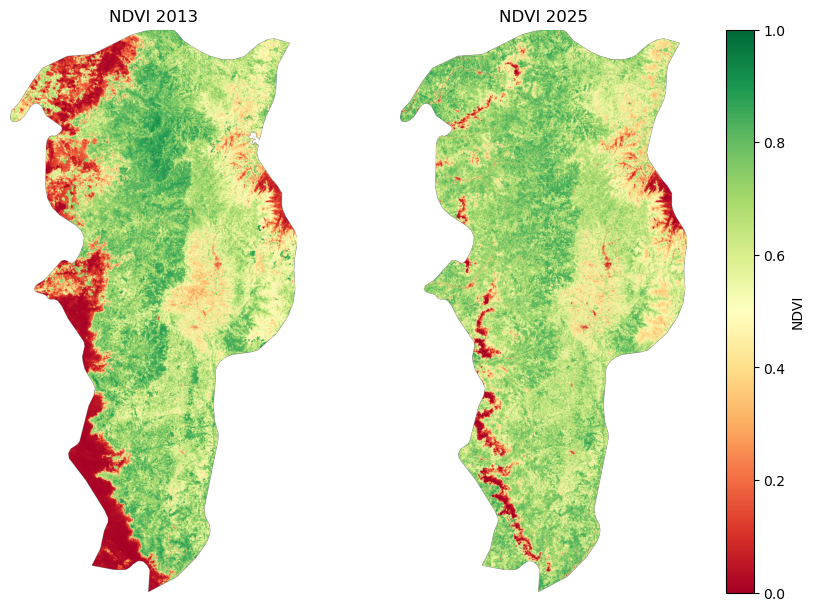

In [13]:
#Plot NDVI fine resolution 2013 and 2025

# File paths
file_2013 = r"C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\NDVI_fine_2013.tif"
file_2025 = r"C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\NDVI_fine_2025.tif"

# Read NDVI data
with rasterio.open(file_2013) as src:
    ndvi_2013 = src.read(1)  # read first band
    profile = src.profile   # for plotting extents

with rasterio.open(file_2025) as src:
    ndvi_2025 = src.read(1)

# Mask invalid NDVI values (if any)
ndvi_2013 = np.where(ndvi_2013 == src.nodata, np.nan, ndvi_2013)
ndvi_2025 = np.where(ndvi_2025 == src.nodata, np.nan, ndvi_2025)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 6), constrained_layout=True)

# Extent for plotting
extent = [profile['transform'][2], 
          profile['transform'][2] + profile['width']*profile['transform'][0],
          profile['transform'][5] + profile['height']*profile['transform'][4],
          profile['transform'][5]]

# NDVI 2013
im1 = axes[0].imshow(ndvi_2013, cmap='RdYlGn', vmin=0, vmax=1, extent=extent)
axes[0].set_title("NDVI 2013")
axes[0].axis('off')

# NDVI 2025
im2 = axes[1].imshow(ndvi_2025, cmap='RdYlGn', vmin=0, vmax=1, extent=extent)
axes[1].set_title("NDVI 2025")
axes[1].axis('off')

# Shared colorbar
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label('NDVI')

plt.show()

In [ ]:
## Plot slope, rho, baseline, and anomaly2025

# Create display-ready layers for baseline and anomaly

baseline_disp = make_display_layer(baseline_mean_coarse)  # coarse baseline
ndvi_anomaly_2025 = yearly_ndvi_coarse.filter(ee.Filter.eq('year', 2025)).first().select('NDVI') \
                        .subtract(baseline_mean_coarse).rename('NDVI_anomaly')
NDVI_anomaly_2025_disp = make_display_layer(ndvi_anomaly_2025)

# Convert EE images to numpy arrays
slope_img = slope_coarse
rho_img = rho_coarse
baseline_img = baseline_mean_coarse
ndvi_2025 = yearly_ndvi_coarse.filter(ee.Filter.eq('year', 2025)).first()
anomaly_img = ndvi_2025.select('NDVI').subtract(baseline_mean_coarse).rename('NDVI_anomaly')

# Convert to numpy at coarse scale (much smaller memory)
slope_arr = geemap.ee_to_numpy(slope_img, region=region_geom, bands=['slope'])
rho_arr = geemap.ee_to_numpy(rho_img, region=region_geom, bands=['rho'])
baseline_arr = geemap.ee_to_numpy(baseline_img, region=region_geom, bands=['NDVI_baseline'])
anomaly_arr = geemap.ee_to_numpy(anomaly_img, region=region_geom, bands=['NDVI_anomaly'])

# Plot side by side

fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

# NDVI slope
im0 = axes[0].imshow(slope_arr, cmap='RdYlGn', vmin=-0.02, vmax=0.02)
axes[0].set_title("NDVI Slope (coarse)")
axes[0].axis('off')

# NDVI Pearson correlation (rho)
im1 = axes[1].imshow(rho_arr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("NDVI Pearson rho (coarse)")
axes[1].axis('off')

# Baseline NDVI
im2 = axes[2].imshow(baseline_arr, cmap='Greens', vmin=0, vmax=1)
axes[2].set_title(f"NDVI Baseline (<= {BASELINE_END})")
axes[2].axis('off')

# NDVI anomaly 2025
im3 = axes[3].imshow(anomaly_arr, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[3].set_title("NDVI Anomaly 2025 (coarse)")
axes[3].axis('off')

# Add colorbars
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Slope')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Rho')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='NDVI')
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04, label='Anomaly')

plt.show()